_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de regresión.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de regresión.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de clasificación a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta, en función de lo que se solicite. Ten encuenta que las celdas vacías indican cuántas líneas debe ocupar la respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un dataset con un conjunto de datos sobre calidad del aire. El conjunto de datos contiene 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de regresión empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


In [3]:
# imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [4]:
## cargar el dataset

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  
# data (as pandas dataframes) 
df = air_quality.data.features 
df_target = air_quality.data.targets 
  
# metadata 
print(air_quality.metadata) 
  
# variable information 
print(air_quality.variables) 

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [5]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [6]:
## ¿cuántas instancias tiene el dataset?

instancias = df.shape[0]

print(f'{instancias} instancias')

9357 instancias


9357 instancias

In [7]:
## ¿cuál es el tipo de datos de cada una de las columnas?

df.dtypes

Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)        int64
NMHC(GT)           int64
C6H6(GT)         float64
PT08.S2(NMHC)      int64
NOx(GT)            int64
PT08.S3(NOx)       int64
NO2(GT)            int64
PT08.S4(NO2)       int64
PT08.S5(O3)        int64
T                float64
RH               float64
AH               float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [9]:
df.nunique()

Date              391
Time               24
CO(GT)             97
PT08.S1(CO)      1042
NMHC(GT)          430
C6H6(GT)          408
PT08.S2(NMHC)    1246
NOx(GT)           926
PT08.S3(NOx)     1222
NO2(GT)           284
PT08.S4(NO2)     1604
PT08.S5(O3)      1744
T                 437
RH                754
AH               6684
dtype: int64

Según indica la instrucción dtypes de pandas para el df, los tipos asociados a las columnas son:
- Object: Date, Time
- Int: PT08.S1(CO), NMHC(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3)
- Float: CO(GT), C6H6(GT), T, RH, AH

Acudiendo a la documentación oficial del dataset, algunas variables que aquí aparecen como continuas deberían ser categóricas. Sin embargo, pandas las lee como continuas. La confusión se produce en las variables relativas a las respuestas del sensor (PT08.Sx(y)), que no tienen asociada directamente una unidad de medida. Una hipótesis es que, pese a que son variables continuas, el dataset original las cataloga como categóricas al buscar categorizar en niveles las respuestas de los sensores. No obstante, como se observa, realmente son variables continuas. En aquellas que se reflejan los valores reales no hay ninguna confusión entre el dataset original y el leído en pandas.

In [10]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?

categ_cols = df.select_dtypes(include=['object', 'category']).columns
cont_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_categ_cols = len(categ_cols)
num_cont_cols = len(cont_cols)

print(f'Categóricas: {num_categ_cols}')
print(f'Continuas: {num_cont_cols}')

Categóricas: 2
Continuas: 13


Esta respuesta depende de lo que se considere como categórica, pues en ocasiones los atributos tipo 'object' se toman como categóricos. Tomando esto como referencia, en el código se realiza una operación simple que cuenta las columnas tipo object y tipo category, para realizar el conteo de categóricas; y otro de columnas tipo int64 y float64, para las variables continuas. Se obtiene entonces que se tienen 13 variables continuas y 2 categóricas (o pseudocategóricas).

In [11]:
## ¿existen valores nulos en el dataset?

df.isna().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [12]:
df_nulos = (df == -200).sum()
print(df_nulos)

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


En primer lugar se comprueban los valores establecidos como NaN. Se percibe que no existen valores nulos como tal en todo el dataset. Sin embargo, en las especificaciones del dataset se indica que los valores nulos vendrán reflejados con el valor -200. Al realizar un conteo de estos, se observa que claramente existen muchos valores nulos, incluso existe una columna que posee prácticamente todos sus valores nulos.

In [13]:
## ¿cuál es la variable respuesta?¿de qué tipo es?

print(df['CO(GT)'].dtype)
print(df['C6H6(GT)'].dtype)
print(df['NOx(GT)'].dtype)
print(df['NO2(GT)'].dtype)

float64
float64
int64
int64


In [14]:
nulos_por_columna = (df == -200).sum() / len(df) * 100
print(nulos_por_columna)

Date              0.000000
Time              0.000000
CO(GT)           17.986534
PT08.S1(CO)       3.911510
NMHC(GT)         90.231912
C6H6(GT)          3.911510
PT08.S2(NMHC)     3.911510
NOx(GT)          17.516298
PT08.S3(NOx)      3.911510
NO2(GT)          17.548360
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
dtype: float64


Con lo analizado hasta aquí, es posible determinar que las variables candidatas a ser la variable objetivo son CO, C6H6, NOx y NO2. Para poder ser la variable objetivo tiene que ser capaz de medir correctamente la calidad del aire, así como no presentar problemas de completitud. Como se observa, tanto CO, NOx y NO2 tienen una alta tasa de valores nulos (17%), mientras que C6H6 apenas presenta un 4% de nulos, porcentaje que además presentan todas las demás features del dataset. Esta información podría ser clave para determinar que la variable objetivo debe ser C6H6, que es de tipo float64

In [15]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2? 

df = df.replace(-200, np.nan)

variables = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']
estadisticos = df[variables].describe()
print(estadisticos)

            CO(GT)      NOx(GT)      NO2(GT)
count  7674.000000  7718.000000  7715.000000
mean      2.152750   246.896735   113.091251
std       1.453252   212.979168    48.370108
min       0.100000     2.000000     2.000000
25%       1.100000    98.000000    78.000000
50%       1.800000   180.000000   109.000000
75%       2.900000   326.000000   142.000000
max      11.900000  1479.000000   340.000000


En primer lugar, como los nulos están establecidos con un valor -200, es necesario sustituirlos por valor NaN, al menos para el análisis de los estadísticos. De no hacerlo, no se estaría reflejando fielmente el dataset.
Las variables CO y NOx tienen una variabilidad muy alta en las meidiciones ya que tienen una alta desviación estándar. Además, sus máximos son mucho más añltos que la media, lo que también sugiere que la distribución está sesgada y tiene una cola larga hacia la derecha. Los máximos también son mucho mayores que el percentil 75, lo que indica esta cola hacia la derecha.
NO2 también presenta una alta variabilidad debido a la desviación y al valor máximo. Sin embargo, esta presenta una concentración mayor de los datos en el rango del percentil 50, ya que la mediana está mucho más cerca de la media que los anteriores. La distribuciójn en su conjunto se muestra asimétrica como las anteriores, con una tendencia hacia los valores extremadamente altos.
La características comunes a las tres distribuciones son el sesgo hacia la derecha y la gran variabilidad en los datos.


¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


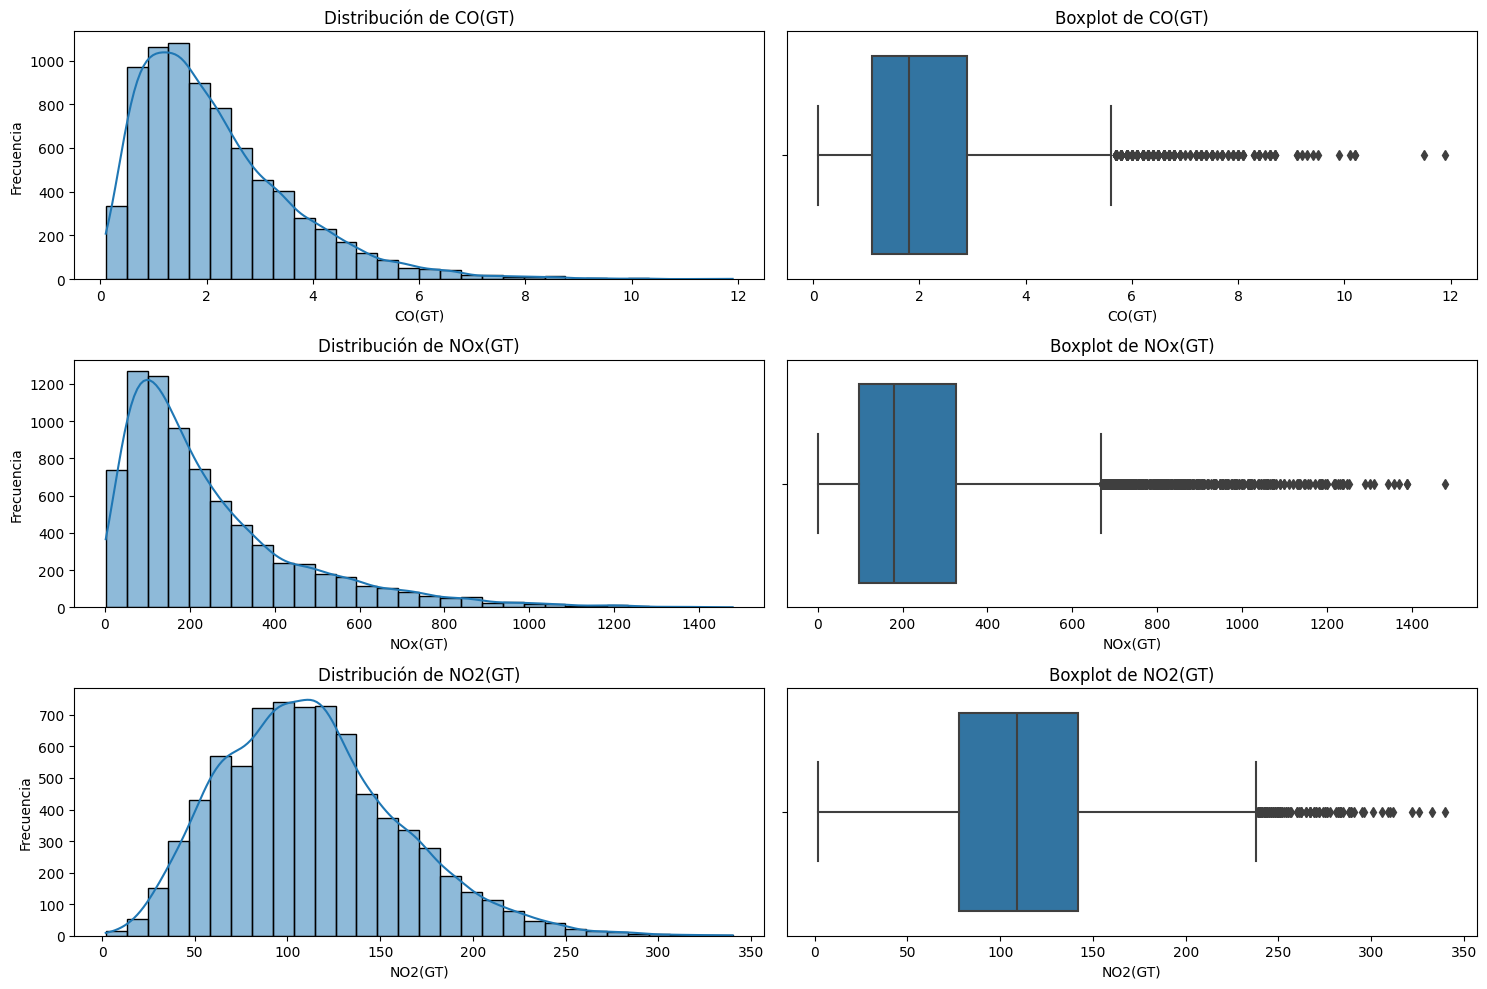

In [16]:
variables = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']

plt.figure(figsize=(15, 10))

for i, var in enumerate(variables, 1):
    plt.subplot(3, 2, i*2-1) 
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

for i, var in enumerate(variables, 1):
    plt.subplot(3, 2, i*2)
    sns.boxplot(x=df[var])
    plt.title(f'Boxplot de {var}')
    plt.xlabel(var)

plt.tight_layout()
plt.show()

Para obtener conclusiones más robustas que confirmen las hipótesis extraídas de los estadísticos, se han dibujado las distribuciones y los diagramas de caja (para detectar outliers) de las tres características. De esta manera, es posible determinar visualmente la respuesta a las preguntas formuladas. 
Las distribuciones, como se comentaba, tienen una tenencia hacia la derecha y los valores altos. Tanto CO como NO2 tienen distribuciones similares. NO2 tiene una distribución más concentrada en los valores bajos, dada su coincidencia entre la media y la mediana, pero también presenta esta tendencia.
En cuanto a valores faltantes, todas poseen nulos, ya que el número de instancias total es de 9357 y CO, NOx y NO2 tienen 7674, 7718 y 7715 valores no nulos, respectivamente.
Por último, sí existen valores anómalos o outliers. Como se observa en los diagramas de caja, todas tienen valores anómalos hacia la derecha. Haciendo un análisis de de ellos, NOx tiene un valor de 1479, que es significativamente alto con respecto a la media.

In [17]:
## ¿cómo son las correlaciones entre las variables del dataset?

df_numeric = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = df_numeric.corr()

correlation_matrix


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.000000,0.879288,0.889734,0.931078,0.915514,0.795028,-0.703446,0.683343,0.630703,0.854182,0.022109,0.048890,0.048556
PT08.S1(CO),0.879288,1.000000,0.790670,0.883795,0.892964,0.713654,-0.771938,0.641529,0.682881,0.899324,0.048627,0.114606,0.135324
NMHC(GT),0.889734,0.790670,1.000000,0.902559,0.877696,0.812685,-0.771135,0.731193,0.853267,0.766723,0.391587,-0.191454,0.269738
C6H6(GT),0.931078,0.883795,0.902559,1.000000,0.981950,0.718839,-0.735744,0.614474,0.765731,0.865689,0.198956,-0.061681,0.167972
PT08.S2(NMHC),0.915514,0.892964,0.877696,0.981950,1.000000,0.704435,-0.796703,0.646245,0.777254,0.880578,0.241373,-0.090380,0.186933
NOx(GT),0.795028,0.713654,0.812685,0.718839,0.704435,1.000000,-0.655707,0.763111,0.233731,0.787046,-0.269683,0.221032,-0.149323
PT08.S3(NOx),-0.703446,-0.771938,-0.771135,-0.735744,-0.796703,-0.655707,1.000000,-0.652083,-0.538468,-0.796569,-0.145112,-0.056740,-0.232017
NO2(GT),0.683343,0.641529,0.731193,0.614474,0.646245,0.763111,-0.652083,1.000000,0.157360,0.708128,-0.186533,-0.091759,-0.335022
PT08.S4(NO2),0.630703,0.682881,0.853267,0.765731,0.777254,0.233731,-0.538468,0.157360,1.000000,0.591144,0.561270,-0.032188,0.629641
PT08.S5(O3),0.854182,0.899324,0.766723,0.865689,0.880578,0.787046,-0.796569,0.708128,0.591144,1.000000,-0.027172,0.124956,0.070751


Obtenida la matriz de correlaciones entre las variables, se pueden observar varias conclusiones acerca de correlaciones positivas fuertes, correlaciones negativas y correlaciones especialmente débiles.
1. Fuertes: CO-NMHC, CO-C6H6 ó PT08.S2-C6H6
2. Negativas: PT08.S3(NOx) con todas
3. Débiles: T y RH con casi todas.

Salvo casos particulares, destacan las correlaciones positivas, en muchos casos bastante fuertes.

In [18]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?

correlation_with_target = correlation_matrix['C6H6(GT)']

top_correlated = correlation_with_target.drop('C6H6(GT)').sort_values(ascending=False).head(3)

print(top_correlated)

PT08.S2(NMHC)    0.981950
CO(GT)           0.931078
NMHC(GT)         0.902559
Name: C6H6(GT), dtype: float64


Se ha trazado un código que devuelva las tres variables más altamente correladas con la variable objetivo escogida, C6H6. Los resultados han arrojado que las tres más correladas son:
1. PT08.S2(NMHC)
2. CO(GT)
3. NMHC(GT)

In [19]:
## ¿existe alguna variable que no tenga correlación?

correlation_with_target = correlation_matrix['C6H6(GT)']

less_correlated = correlation_with_target.drop('C6H6(GT)').sort_values(ascending=True).head(3)

print(less_correlated)

PT08.S3(NOx)   -0.735744
RH             -0.061681
AH              0.167972
Name: C6H6(GT), dtype: float64


Existe una variable que tiene especialmente poca correlación, prácticamente nula, con la variable objetivo, que es RH.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

Tras realizar el EDA se pueden extraer varias conclusiones, que ayudaran a dar robustez a las decisiones para limpiar el dataset:
1. Muchas columnas coinciden en que tienen 366 nulos, lo que podría indicar que estos nulos se refieren a filas completamente nulas. En ese caso, se podrían eliminar esas filas.
2. La variable objetivo será C6H6, ya que es la que menos nulos tiene y por tanto la que resultados más robustos pueden proporcionar al modelo. Además, mide correctamnete la calidad del aire.
3. La variable NMHC tiene más del 90% de valores nulos, por lo que sería interesante eliminarla completamente, pues no tiene poder predictivo.
4. El resto de valores nulos se podrían imputar con la media, ya que el resto de columnas tienen suficientes datos como para hacerlo de manera confiable.
5. También es interesante destacar la presencia de valores anómalos en las variables analizadas. Existen valores excesivamente altos en alguna de las características.

Con el EDA realizado, se vana realizar las transformaciones necesarias para poder conseguir el dataset limpio para comenzar a implementar los modelos de regresión necesarios


Antes, se va a realizar una comprobación para validar o refutara la hipótesis número 1. Es importante recordar que ya se sustituyeron los valores -200 por NaN.

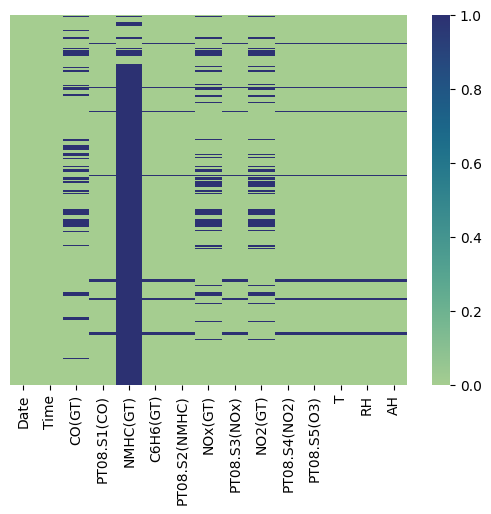

In [20]:
sns.heatmap(df.isna(),yticklabels=False,cmap='crest')
plt.show()

In [21]:
null_rows = df.drop(columns=['Time', 'Date'])[df.drop(columns=['Time', 'Date']).isnull().all(axis=1)]
print("Número de filas completamente vacías (sin 'time' ni 'date'):", null_rows.shape[0])

Número de filas completamente vacías (sin 'time' ni 'date'): 31


Como se observa tanto gráfica como analíticamente en el gráfico anterior, en el df existen 31 filas con todos sus datos nulos. Por ello, estas filas van a ser eliminadas para el análisis.

In [22]:
df_cleaned = df.drop(columns=['Time', 'Date'])
df_cleaned = df_cleaned.dropna(how='all')

df_cleaned['Time'] = df['Time']
df_cleaned['Date'] = df['Date']

In [23]:
# eliminacion de la columna NMHC

df_cleaned.drop(columns=['NMHC(GT)'], inplace=True)

In [24]:
df_cleaned.isna().sum()

CO(GT)           1652
PT08.S1(CO)       335
C6H6(GT)          335
PT08.S2(NMHC)     335
NOx(GT)          1608
PT08.S3(NOx)      335
NO2(GT)          1611
PT08.S4(NO2)      335
PT08.S5(O3)       335
T                 335
RH                335
AH                335
Time                0
Date                0
dtype: int64

In [25]:
# imputacion del rresto de valores nulos con la media (excepto date y time)

columns_to_impute = df_cleaned.select_dtypes(include=[np.number]).columns.difference(['Date', 'Time'])

df_cleaned[columns_to_impute] = df_cleaned[columns_to_impute].fillna(df_cleaned[columns_to_impute].mean())

In [26]:
df_cleaned.isna().sum()

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
Time             0
Date             0
dtype: int64

Ahora, ya no existe ningún valor nulo y se puede comenzar a implementar el modelo de ML que sea necesario con df_cleaned.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algortimo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html 

El algortimo de Regresión Lineal necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primero modelo que se debe construir usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

A continuación, como inidca el enunciado, se realizará un primer modelo utilizando una única variable predictiva.

In [27]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from pandas import DataFrame
from sklearn.model_selection import train_test_split

# seleccionar la variable predictora y la variable target (a predecir)
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción
X = df_cleaned[['PT08.S2(NMHC)']]
y = df_cleaned['C6H6(GT)']

# separar datos de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = DataFrame(scaler.fit_transform(X_train))
X_test = DataFrame(scaler.fit_transform(X_test))

En el fragmento de código anterior se han hecho las preparaciones necesarias. (es importante mencionar que, para darle una buena estructura, se han aunado algunas de las preguntas del enunciado en un sólo fragmento de código, sin el objetivo de que esta técnica conlleve una penalización en la corrección) 

En primer lugar, se han seleccionado en X las variables que se han detectado con poder predictivo, que son todas las de df_cleaned excepto Date, Time y la propia variable que se quiere predecir. EN segundo lugar, en y se selecciona la variable target (C6H6).
POr otro lado, se hace la división entre train y test, sitaundo un 20% de los valores para test y un 80% para train, considerándose una división con suificientes datos para cada uno de los dos subconjuntos. Por último, se normalizan ambos conjuntos mediante el StandardScaler para que la diferencia entre features con valores altos vs bajos no afecte al rendimiento del modelo.

Se ha seleccionado la variable PT08.S2(NMHC) ya que es la que más correlación presentaba con la variable target (0.98)

In [28]:
# entrena el modelo con los datos de entrenamiento

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Con la clase LinearRegression se han entrenado los datos basándose en la variable predictiva X

In [29]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?

coef = model.coef_[0]
intercept = model.intercept_

print(f"Coeficiente: {coef}")
print(f"Intercepto: {intercept}")

Coeficiente: 7.160350291577492
Intercepto: 10.11469439352966


Explica qué indican estos parámetros

Un coeficiente de 7.16 indica que por cada unidad de incremento en la variable X, que en este caso es única, el modelo predice un aumento de 7.16 en la variable y.

Un intercepto de 10.11 indica la predicción para y cuando la variable X es 0. Esto es, si y fuera 0 la variable X valdría 10.11

In [30]:
# realiza las predicciones para el conjunto de datos de test

y_pred_test = model.predict(X_test)

In [31]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso?

Se van a utilizar dos métricas para evaluar el modelo.

1. El MSE, que mide los errores cuadráticos promedio entre las predicciones y los valores reales. Este da una imagen fiel de lo que se están desviando las predicciones del valor real, penalizando las diferencias altas.
2. R2 es utilizado porque permite analizar qué porcentaje de la variación en la variable y es consecuencia y explicado por la variable X, que en este caso es única.

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Mostrar resultados
print(f"Error cuadrático medio: {mse_test:.2f}")
print(f"R^2s: {r2_test:.2f}")

Error cuadrático medio: 2.01
R^2s: 0.96


In [33]:
# ¿Qué error tiene el modelo? Explícalo.

Tiene un MSE de 2.01, que es bastante bajo e indica que las predicciones están muy cercanas a los valores reales.
El r2 también es bajo, indicando que el modelo captura prácticamente toda la variabilidad de los datos originales

Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con todas las variables del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

In [49]:
X = df_cleaned.drop(columns=['C6H6(GT)', 'Date', 'Time'])
y = df_cleaned['C6H6(GT)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = DataFrame(scaler.fit_transform(X_train))
X_test = DataFrame(scaler.fit_transform(X_test))

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [51]:
y_pred = model.predict(X_test)

In [52]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio: {mse}")
print(f"R^2: {r2}")

Error Cuadrático Medio: 1.346178210721162
R^2: 0.9754377741684958


¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

1. El MSE ha disminuido,  lo que indica que el nuevo modelo predice los resultados aún más cercanos a los valores reales
2. El r2 tambien es mejor, indicando que este modelo explica aún mejor la variabilidad de la variable objetivo.

En conclusión, este modelo ha reducido los dos errores que se están evaluando, por lo tanto el modelo es mejor en términos de precisión.

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algortimo de DTRegressor necesitar ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

Indica qué son cada uno de estos hiperparámetros

* criterion: determina la función o mecanismo de evaluación que utiliza el árbol para determinar la calidad de la partición a realizar. Es el criterio que utiliza para determinar esta partición
* splitter: es la estrategia elegida para elegir la divisón de cada nodo, es decir, cómo elige el punto de división para cada nodo del árbol.
* max_depth: indica la profundidad máxima dle árbol, es decir, el número máximo de hojas que pueden exisitr desde la raíz hasta la hoja más profunda.
* min_samples_split: es el número de registros o muestras mínimos que debe tener un nodo para poder dividirse en dos ramas.
* min_samples_leaf: es el número mínimo de muestras que debe haber en una sóla hoja
* max_features: es el número máximo de features que considerará el algoritmo para buscar la mejor división de cada nodo.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

Este hiperparámetro controla la reducción mínima de impureza que se debe lograr para que un único nodo se divida. La pureza se mide evaluando cómo de mezclados están los datos dentro de un nodo, en el caso de la regresión, podría ser la varianza de los valores de cada nodo.
Esto puede ser útil en primer lugar para evitar el overfitting, pues evita que el árbol realice divisiones demasiado concretas de los datos de entrenamiento. Así, ayuda a evitar divisiones que no son relevantes o no producen mejoras para el modelo.

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [38]:
X = df_cleaned.drop(columns=['C6H6(GT)', 'Date', 'Time'])
y = df_cleaned['C6H6(GT)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
model = DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None
)
model.fit(X_train, y_train)

DecisionTreeRegressor(criterion='poisson', max_depth=10, min_samples_leaf=2,
                      min_samples_split=10)

In [40]:
y_pred = model.predict(X_test)

Calcula MAE, R2 y RMSLE

In [41]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))

print(f"MAE: {mae}")
print(f"R^2: {r2}")
print(f"RMSLE: {rmsle}")

MAE: 0.01893544592383487
R^2: 0.9995827670926858
RMSLE: 0.005287253726680712


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

Para comprobar si existe overfitting se analizarán las métricas obtenidas para los datos de entrenamiento. Si estas sonb mucho mejores que las de test, podría existir overfitting

In [42]:
y_train_pred = model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
rmsle_train = np.sqrt(mean_squared_log_error(y_train, y_train_pred))

print(f"MAE (Train): {mae_train}")
print(f"R^2 (Train): {r2_train}")
print(f"RMSLE (Train): {rmsle_train}")

MAE (Train): 0.01079510659722963
R^2 (Train): 0.9997327823928064
RMSLE (Train): 0.003097292537006911


Sí existe overfitting, ya que los resultados de train son mucho mejores, por ejemplo mirando el MAE. El modelo está cometiendo un error mucho mayor en los datos de test. Las otras dos métricas arrojan resultados más similares, pero aún así mejores para los datos de entrenamiento.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.


En general, el modelo de regresión basado en árbol es mejor ya que al ser no lineal, permite capturar relaciones más complejas entre las variables que los modelos lineales (sea lineal o simple). En caso de que la relación entre las variables no sea lineal, a los modelos de regresión lineal les será más complicado encontrar las relaciones. 
Otro aspecto a tener en cuenta es la simplicidad del modelo, pues los árboles de decisión son más propensos al overfitting si no se ajustan bien los hiperparámetros. En este caso, existen indicios bastante visibles de overfitting, por lo que sería necesario ajustar algo más los hiperparámetros para conseguir que el modelo sea claramente mejor a los de regresión lineal.
Los modelos de regresión lineal capturaban los datos de una forma bastante aceptable con unas buenas métricas, y son modelos más sencillos, interpretables y con menor riesgo de overfitting. Si los resultados obtenidos con la regresión lineal se consideran suficientemente altos, esta podría ser una mejor alternativa de modelo ya que es más sencillo de comprender. Sin embargo, si el objetivo principal (como lo es en general) es obtener el mayor rendimiento posible en términos de ajuste a los datos, el árbol de decisión se sitúa como la mejor alternativa, ya que la r2 es mayor a 0.999, mostrando que es capaz de ajustarse a los datos mucho mejor que la regresión simple.

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

EL EDA mostró que podrían existir relaciones entre las variables que no fuesen capturadas por la regresión lineal, dados los valores de correlación.
De todas formas, para comprobar qué modelo obtiene mejores resultados lo mejor es atenerse a las métricas obtenidas. 
La regresión lineal simple aporta resultados significativamente altos, con una r2 de 0.96 en test, aunque con un error cuadratico de aproximadamente dos. Sin embargo, utilizar una única variable no debería ser la mejor aproximación para un modelo. Utilizando una regresión lineal con todas las features se mejoraron los resultados, obteniendo un r2 de 0.975 en test y un mse de 1.35, mejorando claramente lo obtenido con la regresión simple. Esta aproximación captura más información, aunque sigue sin detectar ciertas relaciones entre variables.
Por último, el árbol de decisión, pese a la existencia de un pequeño overfitting, obtiene un r2 d3e 0.999, es decir, casi completo, tanto en train como en test. Los errores en test también son mucho menores a los de la regresión lineal. Esto indica que para este caso concreto la regresión lineal no es capaz de capturar ciertas relaciones complejas no lineales, y por tanto el árbol de decisión se sitúa como la opción que obtiene mejores resultados.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de regresión empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

Stock Market Analysis Using Linear Regression and Decision Tree Regression. Karim, R., Alam, M. K., & Hossain, M. R. (2021). 2021 1st International Conference on Emerging Smart Technologies and Applications (eSmarTA), 10–12 August 2021. IEEE. https://doi.org/10.1109/eSmarTA52612.2021.9515762

título, autores, revista, año de publicación

Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión. Técnicas de regresión empleadas y si realiza alguna adaptación. Principales resultados de la aplicación y de la investigación.

1. Objetivo:  
    El objetivo principal que se establece en esta investigación es predecir el precio de las acciones del mercado bursátil. Para ello, utiliza datos históricos bursátiles de la compañía Amazon. La investigación tiene como objetivo también comparar los modelos de regresión lineal y los árboles de decisión, similarmente a lo que se ha hecho en el experimento propuesto para esta actividad. La diferencia reside en que el criterio a evaluar en esta investigación será evaluar los modelos para diferentes tamños del conjunto de datos

2. Técnicas:  
    Utiliza, como se ha mencionado, dos modelos de aprendizaje automático: regresión lineal y árbol de decisión. Hace varias iteraciones con ellos, probando para el 100% de los datos, el 50% y por último el 25%, con el objetivo de determinar qué modelo responde mejor a los cambios de tamaño ene el conjunto de datos.

3. Resultados:  
    Utilizando el 100% de los datos ambos modelos logran una precisión muy parecida con un r2 de 0.9936, mostrando que ambos modelos funcionan significativamente bien para el conjunto de datos completo.  
    Cuando se reduce el tamaño a la mitad y se coge el 50% del dataset, la regresión linal obtiene una r2 de 0.9796, minetras que el árbol de regresión reduce su precisión hasta una r2 de 0.9088. Esto ya puede indicar signos de la posterior conclusión del estudio.
    Por último, se prueban los modelos con un conjunto de datos que se reduce al 25% del total. EN esta última iteracion, la regresión lineal obtiene una r2 de 0.9723, no mucho más baja que la anterior. Sin embargo, el árbol de decisión consigue un r2 de 0.8353, la cual se ha reducido mucho con respecto a la iteración anterior.

4. Conclusiones de la investigación  
    La investigación concluye con que la regresión lineal es más consistente y efectiva para todos los conjuntos de datos, ya que mantiene una precisión significativamente alta pese a reducir los dataset. El árbol de decisión, pese a que es capaz de detectar las relaciones del total del dataset, su precisión se reduce de manera significativa según se va reduciendo el tamaño del dataset, situándolo como una opción peor en este caso que la regresión lineal. Como se observa, no siempre el árbol de decisión va a ser una mejor opción, como se ha concluido en el experimento de la actividad referido a la predicción de la calidad del aire. Así, es necesario analizar el contexto concreto de cada experimento y la naturaleza y relaciones de y entre sus variables para poder elegir el mejor modelo.